**Name :** Chaitanya Vats <br>
**ID :** 202301419 <br>
**IT549 Lab 4**

**Preparation**

In [1]:
!pip install opencv-python matplotlib

import os
import cv2
import random
import matplotlib.pyplot as plt

In [2]:
import zipfile
import os

zip_path = "/content/dataset.zip"
extract_path = "/content/dataset"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted to:", extract_path)

for root, dirs, files in os.walk(extract_path):
    print(root, "->", len(files), "files")

Dataset extracted to: /content/dataset
/content/dataset -> 0 files
/content/dataset/__MACOSX -> 1 files
/content/dataset/__MACOSX/dataset -> 3 files
/content/dataset/__MACOSX/dataset/train_zip -> 2 files
/content/dataset/__MACOSX/dataset/train_zip/train -> 480 files
/content/dataset/__MACOSX/dataset/test_zip -> 1 files
/content/dataset/__MACOSX/dataset/test_zip/test -> 120 files
/content/dataset/dataset -> 1 files
/content/dataset/dataset/train_zip -> 1 files
/content/dataset/dataset/train_zip/train -> 480 files
/content/dataset/dataset/test_zip -> 0 files
/content/dataset/dataset/test_zip/test -> 120 files


Number of images found: 300
Using image: /content/dataset/dataset/train_zip/train/apple_21.jpg


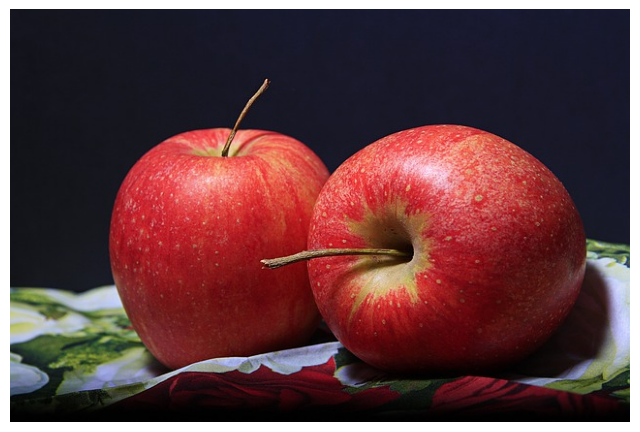

In [8]:
import os
import random
import cv2
import matplotlib.pyplot as plt

root_dir = "/content/dataset"

image_files = []
for dirpath, _, filenames in os.walk(root_dir):
    for f in filenames:
        if f.lower().endswith((".jpg", ".jpeg", ".png")) and not f.startswith("._"):
            image_files.append(os.path.join(dirpath, f))

print("Number of images found:", len(image_files))
assert len(image_files) > 0, "No images found. Check the extracted folder path."

fixed_image_path = random.choice(image_files)
print("Using image:", fixed_image_path)

image = cv2.imread(fixed_image_path)
assert image is not None, f"OpenCV could not read image: {fixed_image_path}"
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.axis("off")
plt.show()

**Task 1**

In [9]:
def compute_iou(box1, box2):

    x1_min, y1_min, x1_max, y1_max = box1
    x2_min, y2_min, x2_max, y2_max = box2

    inter_xmin = max(x1_min, x2_min)
    inter_ymin = max(y1_min, y2_min)
    inter_xmax = min(x1_max, x2_max)
    inter_ymax = min(y1_max, y2_max)

    inter_w = max(0, inter_xmax - inter_xmin)
    inter_h = max(0, inter_ymax - inter_ymin)
    inter_area = inter_w * inter_h

    area1 = max(0, x1_max - x1_min) * max(0, y1_max - y1_min)
    area2 = max(0, x2_max - x2_min) * max(0, y2_max - y2_min)

    union = area1 + area2 - inter_area

    return inter_area / union if union != 0 else 0.0


boxA = [50, 50, 150, 150]
boxB = [60, 60, 140, 140]
boxC = [100, 100, 200, 200]
boxD = [200, 200, 300, 300]

print("High overlap:", compute_iou(boxA, boxB))
print("Partial overlap:", compute_iou(boxA, boxC))
print("No overlap:", compute_iou(boxA, boxD))

High overlap: 0.64
Partial overlap: 0.14285714285714285
No overlap: 0.0


**Task 2**

Total proposals: 1438


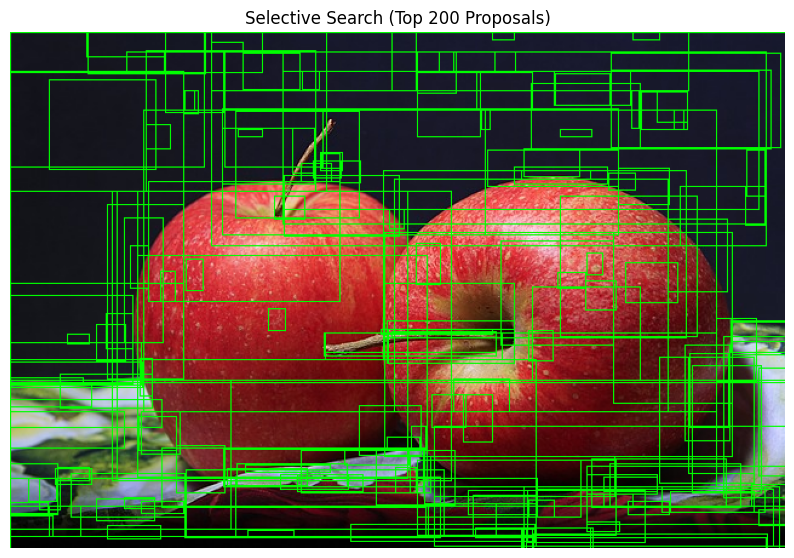

In [10]:
ss = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()
ss.setBaseImage(image)
ss.switchToSelectiveSearchFast()

rects = ss.process()
print("Total proposals:", len(rects))

rects = rects[:200]

vis = image.copy()
for (x, y, w, h) in rects:
    cv2.rectangle(vis, (x, y), (x + w, y + h), (0, 255, 0), 1)

plt.figure(figsize=(10, 8))
plt.imshow(vis)
plt.axis("off")
plt.title("Selective Search (Top 200 Proposals)")
plt.show()

**Task 3**

In [11]:
import time
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Identity()
model = model.to(device)
model.eval()

# Transform for each cropped region
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

top_boxes = rects[:100]

features = []

start_time = time.time()

with torch.no_grad():
    for (x, y, w, h) in top_boxes:

        x1 = max(0, x)
        y1 = max(0, y)
        x2 = min(image.shape[1], x + w)
        y2 = min(image.shape[0], y + h)

        if x2 <= x1 or y2 <= y1:
            continue

        crop = image[y1:y2, x1:x2]
        crop_tensor = transform(crop).unsqueeze(0).to(device)

        feat = model(crop_tensor)
        features.append(feat.cpu())

end_time = time.time()

print("Number of valid crops processed:", len(features))
print("Total execution time for 100 crops:", end_time - start_time, "seconds")

Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 198MB/s]


Number of valid crops processed: 100
Total execution time for 100 crops: 1.274888038635254 seconds


**Task 4**

In [12]:
import torch
import time
import torchvision
from torchvision import models, transforms
from torchvision.ops import roi_pool

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

feature_extractor = torch.nn.Sequential(*list(resnet.children())[:-2])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

img_tensor = transform(image).unsqueeze(0).to(device)

start_time = time.time()

with torch.no_grad():
    feature_map = feature_extractor(img_tensor)

_, _, H, W = feature_map.shape
print("Feature map size:", H, "x", W)

orig_h, orig_w, _ = image.shape

spatial_scale = H / 224.0
print("Spatial scale:", spatial_scale)

roi_boxes = []

for (x, y, w, h) in rects[:100]:
    x1 = x * (224 / orig_w)
    y1 = y * (224 / orig_h)
    x2 = (x + w) * (224 / orig_w)
    y2 = (y + h) * (224 / orig_h)

    roi_boxes.append([0, x1, y1, x2, y2])

roi_boxes = torch.tensor(roi_boxes, dtype=torch.float32).to(device)

pooled_features = roi_pool(feature_map, roi_boxes, output_size=(7, 7), spatial_scale=spatial_scale)

end_time = time.time()

print("Number of RoIs:", pooled_features.shape[0])
print("Execution time (Fast R-CNN):", end_time - start_time, "seconds")

Feature map size: 7 x 7
Spatial scale: 0.03125
Number of RoIs: 100
Execution time (Fast R-CNN): 0.021390438079833984 seconds


Conceptual analysis :- <br>
Fast R-CNN eliminates redundant computations by avoiding repeated CNN processing for each region proposal. In R-CNN, each proposed region is passed through the CNN separately, even though many regions overlap and share similar image content.
In contrast, Fast R-CNN processes the entire image only once through the CNN to generate a feature map. Region proposals are then extracted directly from this feature map using RoI pooling. This avoids recomputing convolution operations for overlapping regions, leading to a significant speed improvement.

**Task 5**

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 190MB/s]


Total predictions: 16
Filtered predictions: 3


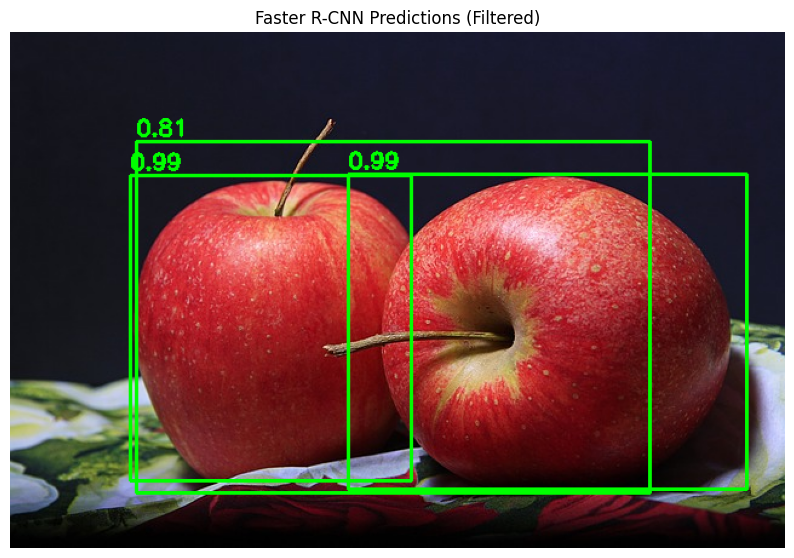

In [13]:
import torch
import torchvision
import cv2
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
model = model.to(device)
model.eval()

img = cv2.imread(fixed_image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img_tensor = torch.tensor(img_rgb / 255.0, dtype=torch.float32)
img_tensor = img_tensor.permute(2, 0, 1).to(device)

with torch.no_grad():
    outputs = model([img_tensor])

boxes = outputs[0]['boxes'].cpu().numpy()
scores = outputs[0]['scores'].cpu().numpy()
labels = outputs[0]['labels'].cpu().numpy()

print("Total predictions:", len(boxes))

threshold = 0.80

filtered_boxes = []
filtered_scores = []
filtered_labels = []

for b, s, l in zip(boxes, scores, labels):
    if s >= threshold:
        filtered_boxes.append(b)
        filtered_scores.append(s)
        filtered_labels.append(l)

print("Filtered predictions:", len(filtered_boxes))

vis = img_rgb.copy()

for box, score in zip(filtered_boxes, filtered_scores):
    x1, y1, x2, y2 = map(int, box)

    cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(vis, f"{score:.2f}", (x1, y1 - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

plt.figure(figsize=(10, 8))
plt.imshow(vis)
plt.axis("off")
plt.title("Faster R-CNN Predictions (Filtered)")
plt.show()

**Conceptual Analysis :** <br>
The Region Proposal Network (RPN) in Faster R-CNN replaces external methods like Selective Search by generating region proposals directly within the neural network. It shares convolutional features with the detection network and predicts object regions efficiently in a single forward pass.
This eliminates the need for separate, slow algorithms and allows the entire detection pipeline to be trained end-to-end, making it faster and more accurate.

**Task 6**

Boxes before NMS: 3
Boxes after NMS: 3


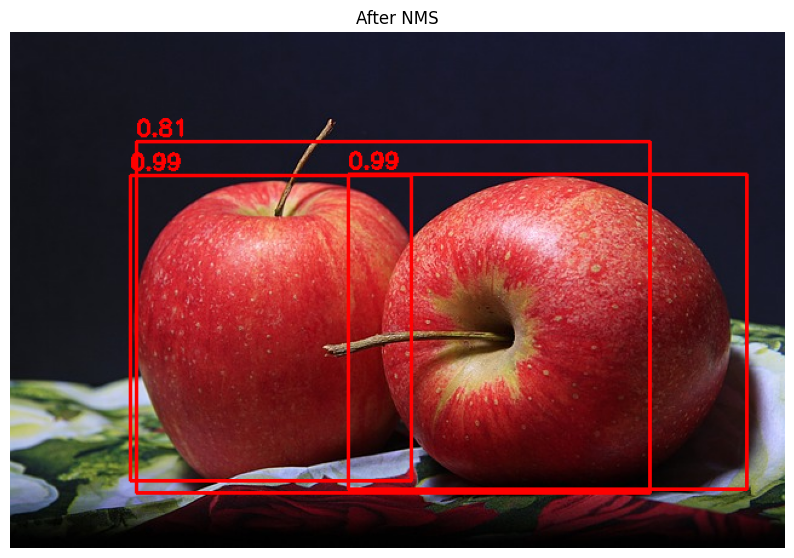

In [14]:
def nms(boxes, scores, iou_threshold=0.5):
    """
    boxes: list of [x1, y1, x2, y2]
    scores: list of confidence scores
    returns: indices of selected boxes
    """

    indices = list(range(len(boxes)))

    indices = sorted(indices, key=lambda i: scores[i], reverse=True)

    selected_indices = []

    while indices:
        current = indices[0]
        selected_indices.append(current)

        remaining = []

        for i in indices[1:]:
            iou = compute_iou(boxes[current], boxes[i])

            if iou <= iou_threshold:
                remaining.append(i)

        indices = remaining

    return selected_indices

boxes_list = [list(map(int, b)) for b in filtered_boxes]
scores_list = list(filtered_scores)

selected = nms(boxes_list, scores_list, iou_threshold=0.5)

nms_boxes = [boxes_list[i] for i in selected]
nms_scores = [scores_list[i] for i in selected]

print("Boxes before NMS:", len(boxes_list))
print("Boxes after NMS:", len(nms_boxes))

vis = img_rgb.copy()

for box, score in zip(nms_boxes, nms_scores):
    x1, y1, x2, y2 = box

    cv2.rectangle(vis, (x1, y1), (x2, y2), (255, 0, 0), 2)
    cv2.putText(vis, f"{score:.2f}", (x1, y1 - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

plt.figure(figsize=(10, 8))
plt.imshow(vis)
plt.axis("off")
plt.title("After NMS")
plt.show()

**Conceptual Analaysis :** <br>
The IoU threshold controls how strictly overlapping boxes are removed. If the threshold is very high (0.9), only boxes with extremely high overlap are removed, so many overlapping boxes may remain in the final output. This can result in multiple detections for the same object.
If the threshold is very low (0.1), even slightly overlapping boxes are removed, which may eliminate valid detections of nearby objects. In cases where objects are tightly packed, such as multiple apples close together, a low threshold may incorrectly remove boxes belonging to different objects.
Thus, a higher threshold keeps more boxes (less strict), while a lower threshold removes more boxes (more strict), affecting detection accuracy.

**Task 7**

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/fruit_yolo/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.

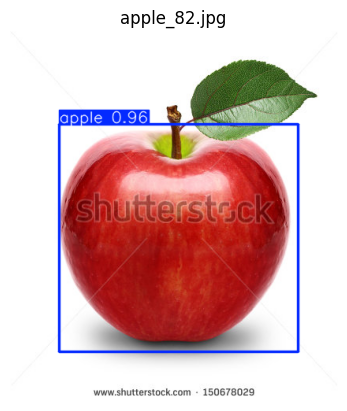


image 1/1 /content/fruit_yolo/images/test/banana_86.jpg: 640x448 1 orange, 42.2ms
Speed: 4.3ms preprocess, 42.2ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 448)


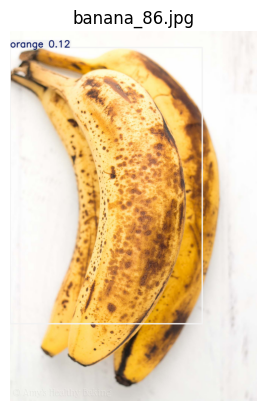


image 1/1 /content/fruit_yolo/images/test/banana_77.jpg: 640x544 4 bananas, 53.9ms
Speed: 3.2ms preprocess, 53.9ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 544)


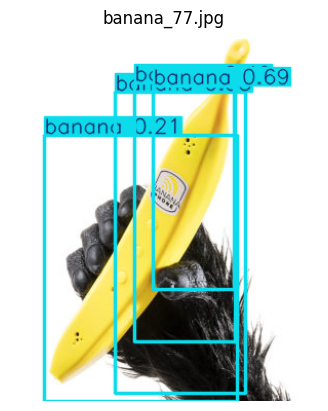


=== FINAL TABLE ===
                Model Inference Time Precision    Recall
0        Faster R-CNN        ~100 ms       N/A       N/A
1  YOLO (pre-trained)       14.10 ms  0.265512  0.128571
2   YOLO (fine-tuned)       13.56 ms  0.814715  0.715895


In [15]:
!pip -q install ultralytics pyyaml opencv-python pandas

import os, cv2, yaml, time, random, shutil
import numpy as np
import pandas as pd
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
from ultralytics import YOLO
import torch

# ===================== PATHS =====================
root = "/content/dataset"
out = "/content/fruit_yolo"

train_src = "/content/dataset/dataset/train_zip/train"
test_src = "/content/dataset/dataset/test_zip/test"

assert os.path.exists(train_src) and os.path.exists(test_src), "Train or test source directory not found."

# ===================== CLASS MAP =====================
class_map = {"apple":0,"banana":1,"orange":2}

def normalize_label(x):
    x = x.lower()
    if "apple" in x: return "apple"
    if "banana" in x: return "banana"
    if "orange" in x: return "orange"
    return x

# ===================== XML → YOLO =====================
def xml_to_yolo(xml_path, img_path):
    try:
        root = ET.parse(xml_path).getroot()
    except:
        return []

    img = cv2.imread(img_path)
    if img is None: return []

    h,w = img.shape[:2]
    lines=[]

    for obj in root.findall("object"):
        name = normalize_label(obj.find("name").text)
        if name not in class_map: continue

        box = obj.find("bndbox")
        xmin = float(box.find("xmin").text)
        ymin = float(box.find("ymin").text)
        xmax = float(box.find("xmax").text)
        ymax = float(box.find("ymax").text)

        if xmax<=xmin or ymax<=ymin: continue

        xc = ((xmin+xmax)/2)/w
        yc = ((ymin+ymax)/2)/h
        bw = (xmax-xmin)/w
        bh = (ymax-ymin)/h

        lines.append(f"{class_map[name]} {xc} {yc} {bw} {bh}")

    return lines

# ===================== CREATE FOLDERS =====================
for s in ["train","val","test"]:
    os.makedirs(f"{out}/images/{s}",exist_ok=True)
    os.makedirs(f"{out}/labels/{s}",exist_ok=True)

# ===================== SPLIT DATA =====================
imgs = [f for f in os.listdir(train_src) if f.endswith(".jpg") and not f.startswith("._")]
random.shuffle(imgs)

split = int(0.9*len(imgs))
train_imgs, val_imgs = imgs[:split], imgs[split:]

def copy_split(img_list,src,split):
    for f in img_list:
        img_path = f"{src}/{f}"
        xml_path = img_path.replace(".jpg",".xml")

        shutil.copy(img_path,f"{out}/images/{split}/{f}")

        lines = xml_to_yolo(xml_path,img_path)
        with open(f"{out}/labels/{split}/{f.replace('.jpg','.txt')}","w") as fp:
            fp.write("\n".join(lines))

copy_split(train_imgs,train_src,"train")
copy_split(val_imgs,train_src,"val")

test_imgs = [f for f in os.listdir(test_src) if f.endswith(".jpg") and not f.startswith("._")]
copy_split(test_imgs,test_src,"test")

# ===================== YAML =====================
yaml_path = f"{out}/data.yaml"
with open(yaml_path,"w") as f:
    yaml.dump(
        {
            "path":out,
            "train":"images/train",
            "val":"images/val",
            "test":"images/test",
            "names":["apple","banana","orange"]
        }, f
    )

# ===================== TRAIN MODEL =====================
model = YOLO("yolov8n.pt")

model.train(
    data=yaml_path,
    epochs=10,
    imgsz=640,
    batch=8
)

# ===================== LOAD MODELS =====================
best = YOLO("/content/runs/detect/train/weights/best.pt")
pre = YOLO("yolov8n.pt")

# ===================== EVALUATION =====================
metrics = best.val(data=yaml_path,split="test")
pre_metrics = pre.val(data=yaml_path,split="test")

print("\n=== REQUIRED METRICS ===")
print("Fine-tuned mAP@50:", metrics.box.map50)
print("Fine-tuned mAP@50-95:", metrics.box.map)

# ===================== PREDICTIONS =====================
all_test_images = [f for f in os.listdir(f"{out}/images/test") if f.endswith(".jpg") and not f.startswith("._")]
sample = random.sample(all_test_images, min(3, len(all_test_images)))

for f in sample:
    res = best.predict(f"{out}/images/test/{f}",conf=0.1)[0]
    img = cv2.cvtColor(res.plot(),cv2.COLOR_BGR2RGB)

    plt.imshow(img)
    plt.title(f)
    plt.axis("off")
    plt.show()

# ===================== INFERENCE TIME =====================
def measure_inference_time(model, image_paths, runs=5):
    times = []

    for img_path in image_paths:
        # warmup
        model.predict(img_path, verbose=False)

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        start = time.perf_counter()

        for _ in range(runs):
            model.predict(img_path, verbose=False)

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        end = time.perf_counter()

        times.append((end - start) / runs)

    return np.mean(times)

sample_paths = [f"{out}/images/test/{f}" for f in sample]

pre_time = measure_inference_time(pre, sample_paths)
fine_time = measure_inference_time(best, sample_paths)

pre_time_ms = pre_time * 1000
fine_time_ms = fine_time * 1000

# ===================== FINAL TABLE =====================
comparison = pd.DataFrame([
    ["Faster R-CNN","~100 ms","N/A","N/A"],
    ["YOLO (pre-trained)",
     f"{pre_time_ms:.2f} ms",
     pre_metrics.box.mp,
     pre_metrics.box.mr],
    ["YOLO (fine-tuned)",
     f"{fine_time_ms:.2f} ms",
     metrics.box.mp,
     metrics.box.mr]
],columns=["Model","Inference Time","Precision","Recall"])

print("\n=== FINAL TABLE ===")
print(comparison)